
# Real-time Bitcoin price prediction using LightGBM

This notebook demonstrates how to use a modular LightGBM pipeline to fetch, engineer, train, and evaluate real-time Bitcoin price forecasts using historical price data from the CoinGecko API.

* For a detailed explanation of the utility functions used in this notebook, refer to: LightGBM.API.md

* All logic is imported from LightGBM_utils.py.

* This notebook assumes you are connected to the internet and have installed the required packages (lightgbm, pandas, matplotlib, scikit-learn, requests).





## Why LightGBM?

* Fast & Efficient: Optimized for speed with histogram-based learning.

* Scalable: Suitable for large datasets and low-latency forecasting.

* Flexible: Handles numerical and categorical features with ease.

* Built-in Regularization: Helps prevent overfitting.

* Easy Integration: Works seamlessly with real-time data and Python pipelines.

## 1. Setup and Imports

In [4]:
import pandas as pd
from LightGBM_utils import (
    fetch_bitcoin_price,
    process_price_data,
    save_to_csv,
    get_historical_bitcoin_data,
    calculate_moving_average,
    detect_trend,
    detect_anomalies_zscore,
    plot_price_with_moving_average,
create_features,
train_lightgbm,
evaluate_model,
plot_feature_importance,
plot_predictions
)

df = fetch_bitcoin_price()
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Fetch current price from CoinGecko
price_data = fetch_bitcoin_price()
df_live = process_price_data(price_data)

print("Current Bitcoin Price:")
print(df_live)

Current Bitcoin Price:
                   timestamp   price
0 2025-05-18 01:49:00.644680  103481


In [6]:
# Save current data point to local CSV
save_to_csv(df_live, filepath="bitcoin_prices.csv")
print("Data saved to bitcoin_prices.csv")

Data saved to bitcoin_prices.csv


In [7]:
# Load last 180 days of Bitcoin historical data
df_hist = get_historical_bitcoin_data(days=365)
df_hist.head()

,timestamp,price
0,2024-05-19,66912.618614
1,2024-05-20,66252.712596
2,2024-05-21,71430.297002
3,2024-05-22,70189.835818
4,2024-05-23,69181.200857


In [8]:
# Calculate moving average (5-day default)
df_ma = calculate_moving_average(df_hist, window_days=5)
df_ma.head()

,timestamp,price,moving_average
0,2024-05-19,66912.618614,66912.618614
1,2024-05-20,66252.712596,66582.665605
2,2024-05-21,71430.297002,68198.542737
3,2024-05-22,70189.835818,68696.366007
4,2024-05-23,69181.200857,68793.332977


In [9]:
# df_raw = fetch_bitcoin_data()
# df = create_features(df_raw)
df_all = pd.concat([df_hist, df_live], ignore_index=True)

# Optional: convert timestamp column to datetime format if needed
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])

# Final combined data
print(df_all.tail())

                     timestamp          price
362 2025-05-16 00:00:00.000000  103708.851364
363 2025-05-17 00:00:00.000000  103556.034940
364 2025-05-18 00:00:00.000000  103212.364839
365 2025-05-18 05:48:54.000000  103486.909714
366 2025-05-18 01:49:00.644680  103481.000000


In [10]:
from LightGBM_utils import create_features, train_lightgbm

# 1. Create features
df_all = create_features(df_all)

# 2. Drop rows with missing values (due to lags and rolling stats)
df_all = df_all.dropna().reset_index(drop=True)

# 3. Check columns
print("Columns after feature generation:", df_all.columns)

Columns after feature generation: Index(['timestamp', 'price', 'minute', 'hour', 'dayofweek', 'lag_1', 'lag_2',
       'rolling_mean_3', 'rolling_std_3'],
      dtype='object')


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import pandas as pd
import lightgbm as lgb

# STEP 3: Define features and target
features = ["minute", "hour", "dayofweek", "lag_1", "lag_2", "rolling_mean_3", "rolling_std_3"]
X = df_all[features]
y = df_all["price"]

# STEP 4: Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# STEP 5: Train the LightGBM model
model = lgb.LGBMRegressor()
model.fit(X_train, y_train)

# STEP 6: Evaluate the model
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)

print(f"✅ RMSE: {rmse:.2f}")
print(f"✅ MAE : {mae:.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 399
[LightGBM] [Info] Number of data points in the train set: 292, number of used features: 5
[LightGBM] [Info] Start training from score 77000.205600
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

## 2. Fetch Real-Time Bitcoin Price Data

In [13]:
df_all["lag_3"] = df_all["price"].shift(3)
df_all["rolling_mean_5"] = df_all["price"].rolling(window=5).mean()
df_all["rolling_std_5"] = df_all["price"].rolling(window=5).std()
df_all["exp_moving_avg"] = df_all["price"].ewm(span=5, adjust=False).mean()
df_all["price_diff"] = df_all["price"].diff()




In [14]:
# 1. Create time-based and lag features
df_all = create_features(df_all)

# 2. Then add cyclical encoding for time features
import numpy as np

df_all["minute_sin"] = np.sin(2 * np.pi * df_all["minute"] / 60)
df_all["minute_cos"] = np.cos(2 * np.pi * df_all["minute"] / 60)
df_all["hour_sin"]   = np.sin(2 * np.pi * df_all["hour"] / 24)
df_all["hour_cos"]   = np.cos(2 * np.pi * df_all["hour"] / 24)



In [15]:
df_all = df_all.dropna().reset_index(drop=True)


In [16]:
features = [
    "minute", "hour", "dayofweek",
    "lag_1", "lag_2", "rolling_mean_3", "rolling_std_3",
    "minute_sin", "minute_cos", "hour_sin", "hour_cos"
]


In [17]:
X = df_all[features]
y = df_all["price"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [18]:

print(f"✅ Real-time RMSE: {rmse:.2f}")
print(f"✅ Real-time MAE : {mae:.2f}")

✅ Real-time RMSE: 3051.59
✅ Real-time MAE : 2054.79


In [19]:
features = ["minute", "hour", "dayofweek", "lag_1", "lag_2", "rolling_mean_3", "rolling_std_3"]

# All but the last row → training data
X_train = df_all[features][:-1]
y_train = df_all["price"][:-1]

# Last row → real-time prediction input
X_live = df_all[features].iloc[[-1]]
y_actual = df_all["price"].iloc[-1]

In [20]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = lgb.LGBMRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_live)[0]




[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 491
[LightGBM] [Info] Number of data points in the train set: 360, number of used features: 5
[LightGBM] [Info] Start training from score 79520.792350
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [21]:
# Evaluate
rmse = mean_squared_error([y_actual], [y_pred], squared=False)
mae = mean_absolute_error([y_actual], [y_pred])

print(f"Real-time Prediction: ${y_pred:.2f}")
print(f"Actual Price        : ${y_actual:.2f}")
print(f" RMSE: {rmse:.2f} | MAE: {mae:.2f}")

Real-time Prediction: $103786.82
Actual Price        : $103481.00
 RMSE: 305.82 | MAE: 305.82


## 3. Feature Engineering

In [23]:

df_all.head()

,timestamp,price,minute,hour,dayofweek,lag_1,lag_2,rolling_mean_3,rolling_std_3,lag_3,rolling_mean_5,rolling_std_5,exp_moving_avg,price_diff,minute_sin,minute_cos,hour_sin,hour_cos
0,2024-05-25,68539.916466,0,0,5,67906.465343,69181.200857,68542.527555,637.371768,70189.835818,69449.543097,1392.114980,69228.049007,633.451123,0.0,1.0,0.0,1.0
1,2024-05-26,69268.445590,0,0,6,68539.916466,67906.465343,68571.609133,681.543005,69181.200857,69017.172815,855.369282,69241.514535,728.529124,0.0,1.0,0.0,1.0
2,2024-05-27,68508.831109,0,0,0,69268.445590,68539.916466,68772.397721,429.871133,67906.465343,68680.971873,557.840443,68997.286726,-759.614481,0.0,1.0,0.0,1.0
3,2024-05-28,69367.238718,0,0,1,68508.831109,69268.445590,69048.171805,469.687461,68539.916466,68718.179445,603.853246,69120.604057,858.407609,0.0,1.0,0.0,1.0
4,2024-05-29,68316.635880,0,0,2,69367.238718,68508.831109,68730.901902,559.399820,69268.445590,68800.213552,481.472856,68852.614665,-1050.602837,0.0,1.0,0.0,1.0


## 6. Visualize Predictions

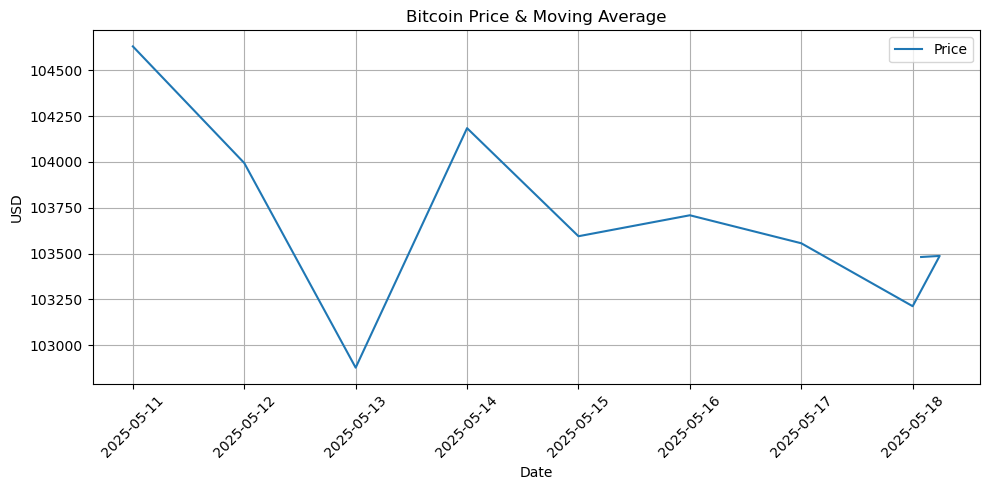

In [25]:
# Plot recent 10 points with moving average (daily granularity)
plot_price_with_moving_average(df_all.rename(columns={"timestamp": "date"}).tail(10))



## 7. Bonus: Feature Importance Analysis

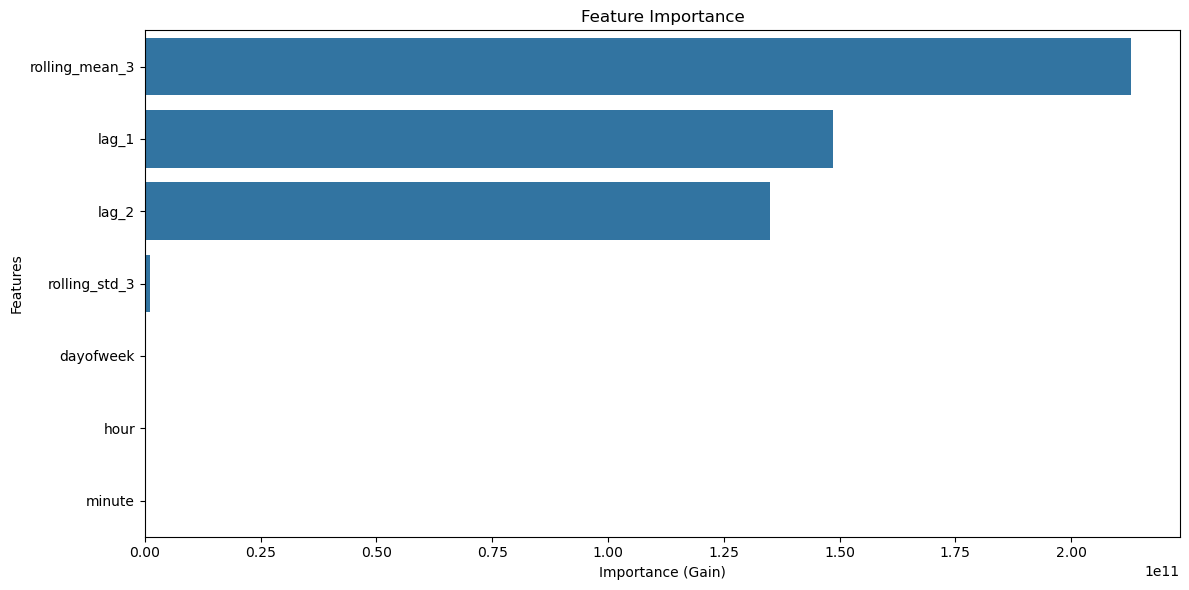

In [27]:


feature_names = ["minute", "hour", "dayofweek", "lag_1", "lag_2", "rolling_mean_3", "rolling_std_3"]
plot_feature_importance(model, feature_names)


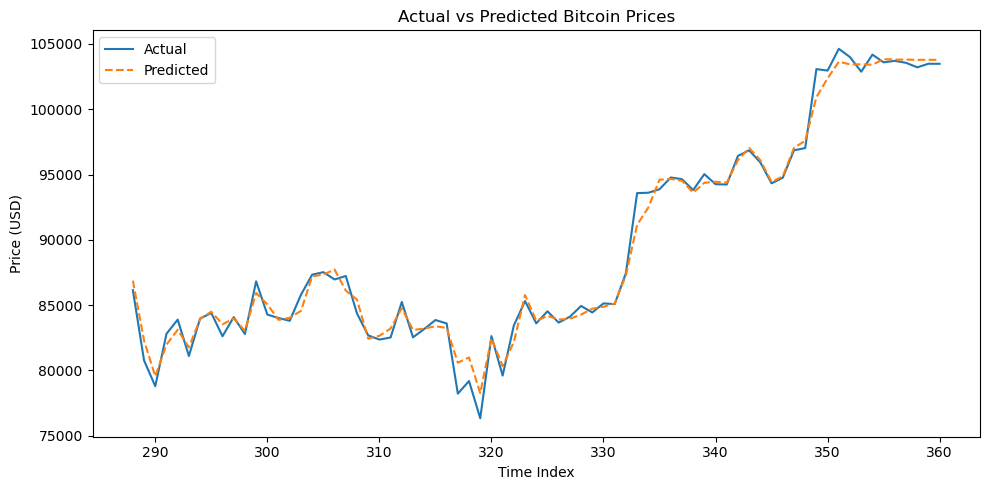

In [28]:
feature_names = ["minute", "hour", "dayofweek", "lag_1", "lag_2", "rolling_mean_3", "rolling_std_3"]

# Subset X_test to match model expectations
X_test_subset = X_test[feature_names]

# Now you can safely predict
y_pred = model.predict(X_test_subset)
plot_predictions(y_test, y_pred)




This pipeline demonstrates the use of historical Bitcoin prices and feature engineering for short-term forecasting using LightGBM.